# 02 - Analisis exploratorio

Objetivo: entender distribuciones, churn por segmento y problemas de calidad antes de preparar la base de modelado.

El foco es separar senales utiles de variables que podrian introducir sesgo o leakage.

In [1]:
import churn_analysis_portfolio.missing  # registers df.missing


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import missingno
import upsetplot

sns.set_style("whitegrid")

DATA_PATH = "../data/Customer_Data.csv"
TARGET_COL = "Customer_Status"
MONTHLY_CHARGE_COL = "Monthly_Charge"
INTERNET_DEPENDENT_COLS = [
    "Internet_Type",
    "Online_Security",
    "Online_Backup",
    "Device_Protection_Plan",
    "Premium_Support",
    "Streaming_TV",
    "Streaming_Movies",
    "Streaming_Music",
    "Unlimited_Data",
]

df = pd.read_csv(DATA_PATH)
df_model = df[df[TARGET_COL].isin(["Stayed", "Churned"])].copy()
df_joined = df[df[TARGET_COL] == "Joined"].copy()

## Variables numericas (df_model)

In [3]:
numeric_cols = [
    "Age", "Number_of_Referrals", "Tenure_in_Months",
    "Monthly_Charge", "Total_Charges", "Total_Revenue",
]
df_model[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,6007.0,47.289163,16.805110,18.00,33.000,47.00,60.000,84.00
Number_of_Referrals,6007.0,7.439820,4.622369,0.00,3.000,7.00,11.000,15.00
Tenure_in_Months,6007.0,17.394540,10.592920,1.00,8.000,17.00,27.000,36.00
Monthly_Charge,6007.0,65.087598,31.067808,-10.00,35.950,71.10,90.450,118.75
Total_Charges,6007.0,2430.986173,2267.481294,19.10,539.950,1556.85,4013.900,8684.80
Total_Revenue,6007.0,3233.246021,2856.181082,21.61,833.685,2367.15,5105.685,11979.34


## Churn rate por segmento

Se comparan 4 variables categoricas con volumen de clientes desigual entre categorias (`Contract`, `Internet_Service`, `Value_Deal`, `Payment_Method`). Por eso cada barra muestra tambien `n`: una tasa de churn alta calculada sobre pocos clientes no deberia leerse igual que una calculada sobre miles.

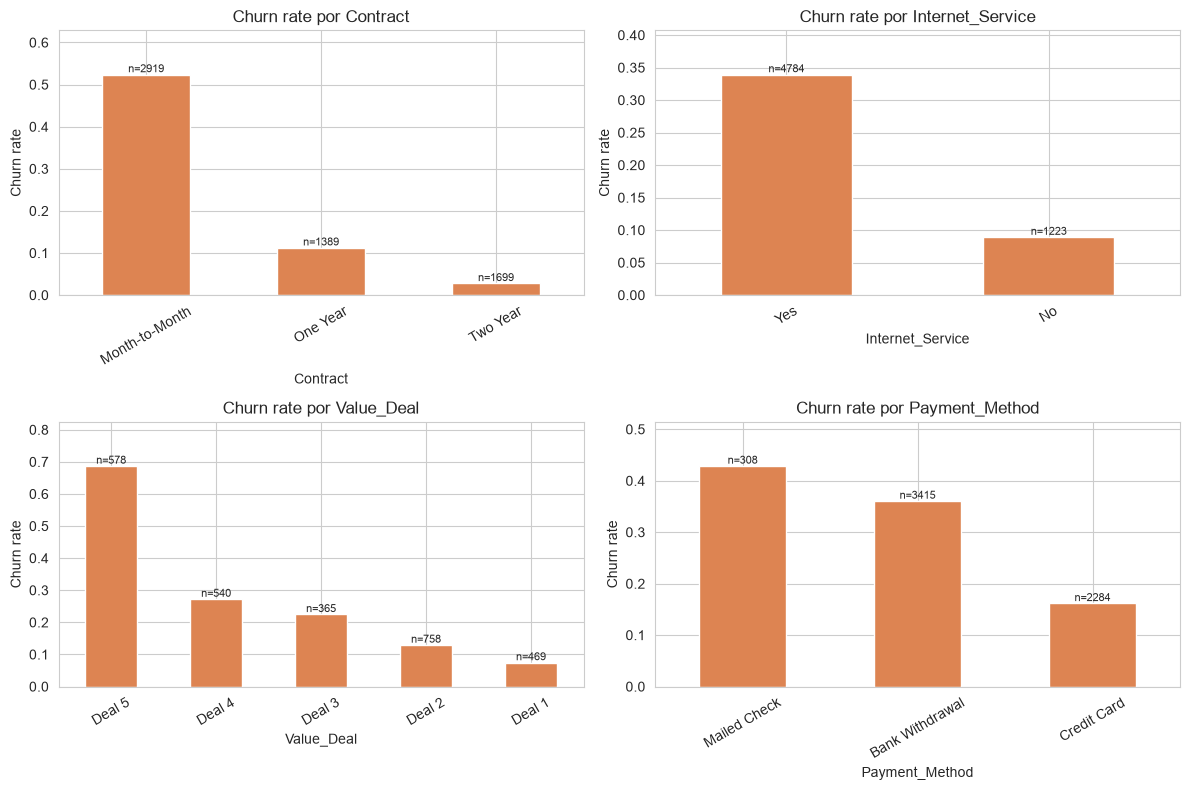

In [4]:
segment_cols = ["Contract", "Internet_Service", "Value_Deal", "Payment_Method"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, segment_cols):
    grouped = df_model.groupby(col)[TARGET_COL]
    churn_rate = grouped.apply(lambda s: (s == "Churned").mean()).sort_values(ascending=False)
    counts = grouped.size().reindex(churn_rate.index)

    bars = churn_rate.plot(kind="bar", ax=ax, color="#DD8452")
    for bar, n in zip(bars.patches, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"n={n}", ha="center", va="bottom", fontsize=8,
        )
    ax.set_title(f"Churn rate por {col}")
    ax.set_ylabel("Churn rate")
    ax.set_ylim(0, churn_rate.max() * 1.2)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Anomalia: `Monthly_Charge` negativo

El dataset contiene 107 filas (1.7%) con `Monthly_Charge` negativo, entre -1 y -10. Un cargo mensual negativo no tiene una interpretacion de negocio evidente por si solo -- podria ser un descuento/reembolso real, o un error de captura. Hay que revisar el patron antes de decidir que hacer con estas filas.

In [5]:
negative_mask = df[MONTHLY_CHARGE_COL] < 0
print(f"Filas con Monthly_Charge negativo: {negative_mask.sum()} ({negative_mask.mean():.1%})")
df.loc[negative_mask, MONTHLY_CHARGE_COL].value_counts().sort_index()

Filas con Monthly_Charge negativo: 107 (1.7%)


Monthly_Charge
-10.0    12
-9.0      8
-8.0     12
-7.0     14
-6.0      5
-5.0     11
-4.0     14
-3.0     11
-2.0     10
-1.0     10
Name: count, dtype: int64

Los 107 valores son todos numeros enteros (-1, -2, ..., -10, sin decimales). Un descuento o reembolso real heredaria los centavos del resto de la base -- si son numeros redondos con esa consistencia, es mas probable que sean valores sinteticos que una regla de negocio real. Se compara la proporcion de valores enteros entre negativos y no negativos para confirmarlo.

In [6]:
is_whole_number = lambda s: (s.dropna() % 1 == 0)

negative_whole_pct = is_whole_number(df.loc[negative_mask, MONTHLY_CHARGE_COL]).mean()
non_negative_whole_pct = is_whole_number(df.loc[~negative_mask, MONTHLY_CHARGE_COL]).mean()

print(f"% valores enteros entre negativos:     {negative_whole_pct:.1%} (n={negative_mask.sum()})")
print(f"% valores enteros entre no negativos:  {non_negative_whole_pct:.1%} (n={(~negative_mask).sum()})")

% valores enteros entre negativos:     100.0% (n=107)
% valores enteros entre no negativos:  5.5% (n=6311)


### Conclusion

100% de los valores negativos son enteros, frente a ~5.5% entre los no negativos -- una diferencia demasiado grande para ser casualidad. Un descuento o reembolso real no produciria ese patron tan limpio; es evidencia de valores sinteticos o de captura defectuosa, no de una regla de negocio (y el patron no se explica por `Customer_Status` ni `Value_Deal` -- aparece en los tres estados y con/sin deal). Por eso se excluyen antes de entrenar y puntuar clientes en `04_train_test_split.ipynb`. El pipeline de dbt conserva el valor crudo sin modificar y solo lo marca con `has_negative_monthly_charge` (ver `docs/dbt-models.md`), asi que esta decision es especifica del modelo, no una limpieza global del dato.

## Nulos en columnas de servicio: ¿error o patron estructural?

`Internet_Type`, `Online_Security`, `Online_Backup`, `Device_Protection_Plan`, `Premium_Support`, `Streaming_TV`, `Streaming_Movies`, `Streaming_Music` y `Unlimited_Data` -- nueve columnas distintas -- comparten exactamente el mismo numero de nulos. Que nueve columnas coincidan al conteo exacto no es casualidad: sugiere que faltan juntas, en las mismas filas.

Hipotesis a probar: esas filas son clientes sin `Internet_Service`, para quienes estas columnas no aplican (no son errores de captura).

<Axes: >

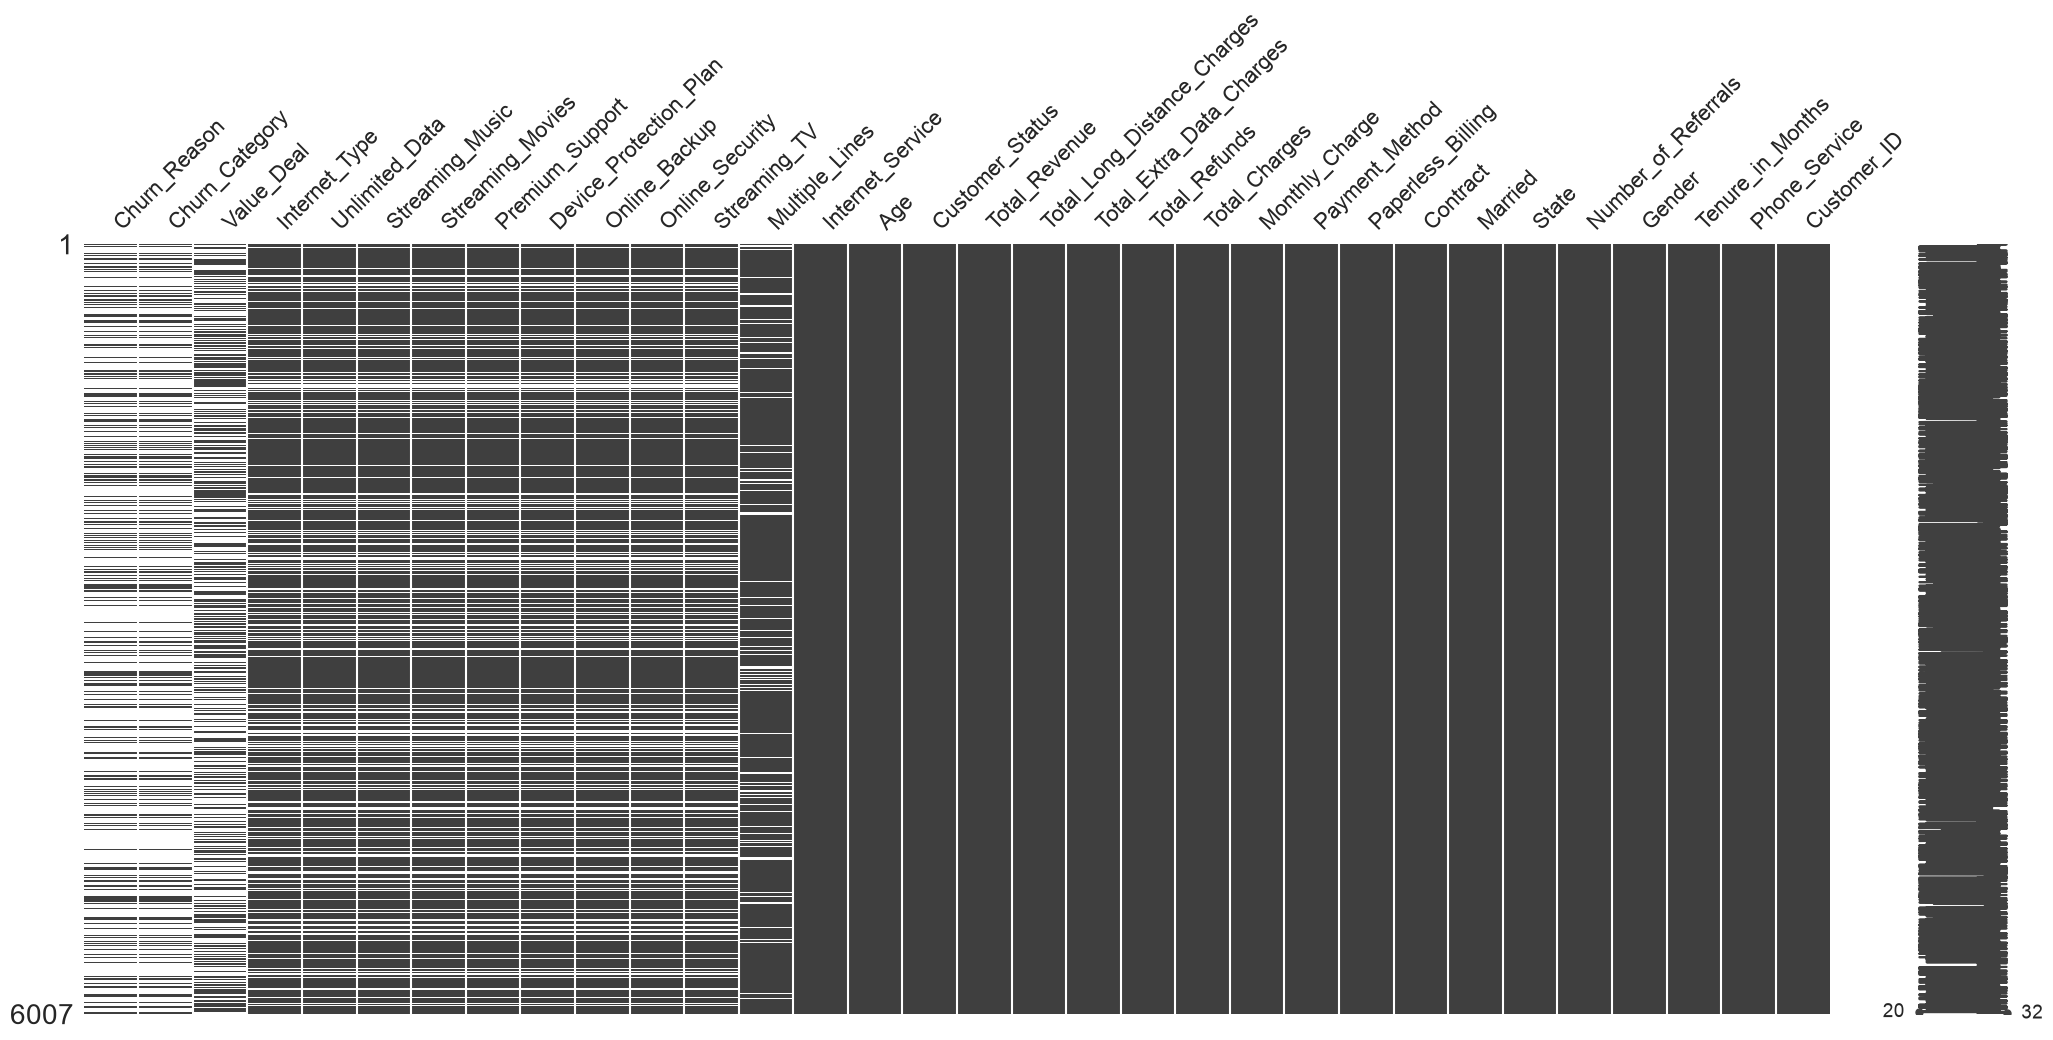

In [7]:
# Visualizacion de nulos ordenados en variables de internet
(
    df_model
    .missing.sort_variables_by_missingness()
    .pipe(missingno.matrix)
)

In [8]:
missing_variables = (
    df_model.missing.missing_variable_summary()
    .query("n_missing > 0")
    .sort_values("n_missing", ascending=False)
)

missing_variables


,variable,n_missing,n_cases,pct_missing
30,Churn_Category,4275,6007,71.166972
31,Churn_Reason,4275,6007,71.166972
7,Value_Deal,3297,6007,54.885966
11,Internet_Type,1223,6007,20.359580
12,Online_Security,1223,6007,20.359580
13,Online_Backup,1223,6007,20.359580
14,Device_Protection_Plan,1223,6007,20.359580
15,Premium_Support,1223,6007,20.359580
16,Streaming_TV,1223,6007,20.359580
17,Streaming_Movies,1223,6007,20.359580


`Churn_Category` y `Churn_Reason` encabezan la tabla (71% missing) pero no se investigan como problema de missing-data: solo existen para clientes que ya churnearon (es su motivo de baja), por lo que son consecuencia del churn, no un predictor -- incluirlas seria leakage directo. Se excluyen del modelo en `04_train_test_split.ipynb`, no se imputan.

El resto de esta seccion se enfoca en las 9 columnas dependientes de internet, que si son nulos verdaderos a explicar.

### Prueba de la hipotesis

Primero, un corte visual: si se ordena `df_model` por `Internet_Service`, la matriz de nulos deberia mostrar un bloque solido de nulos para un grupo y ninguno para el otro. Despues, la tabla siguiente confirma ese corte con numeros exactos: la tasa de nulos debe ser 100% para `Internet_Service == "No"` y 0% para `Internet_Service == "Yes"`.

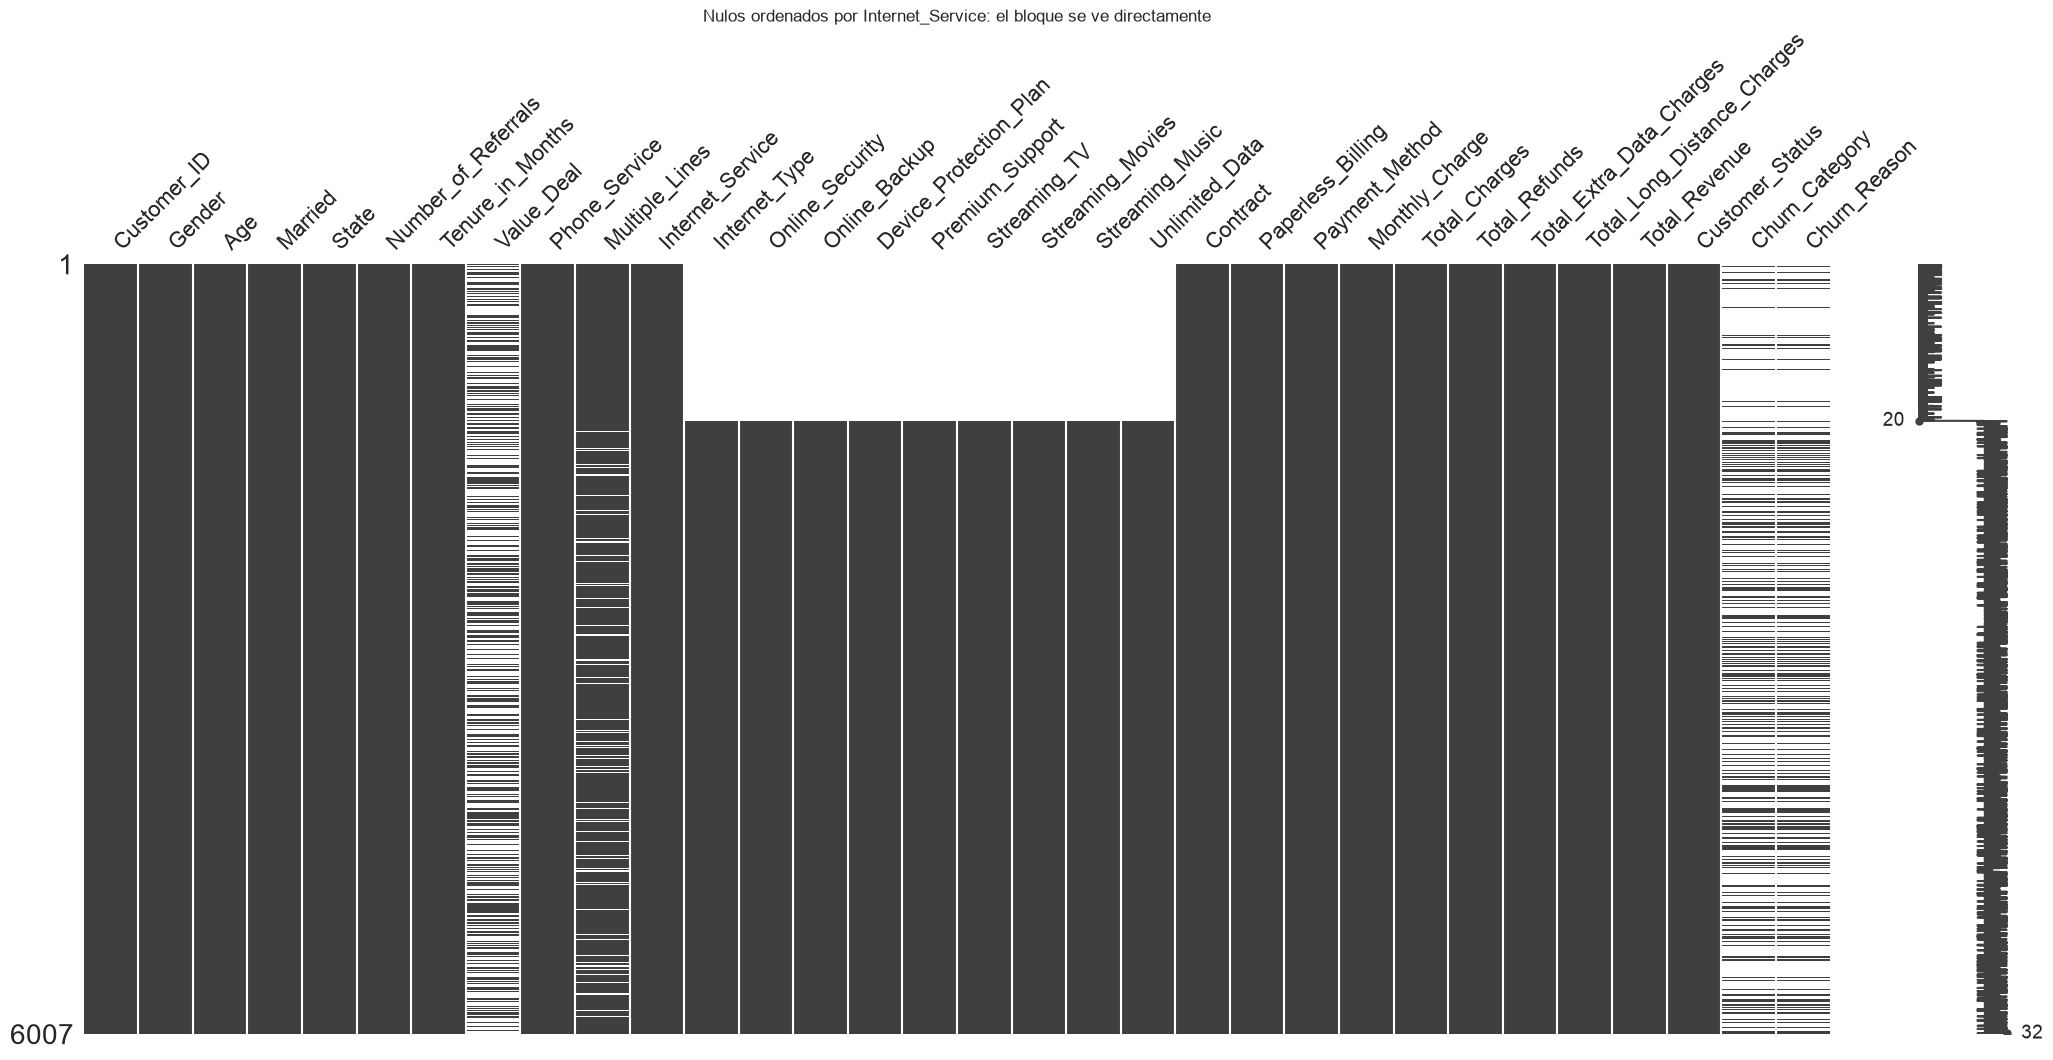

In [9]:
# Corte visual: nulos ordenados por Internet_Service (no por missingness)
ax = (
    df_model
    .sort_values("Internet_Service")
    .pipe(missingno.matrix)
)
ax.set_title("Nulos ordenados por Internet_Service: el bloque se ve directamente")
plt.show()

In [10]:
internet_null_check = pd.DataFrame(
    {
        "variable": INTERNET_DEPENDENT_COLS,
        "n_missing": [df_model[col].isna().sum() for col in INTERNET_DEPENDENT_COLS],
        "n_missing_without_internet": [
            df_model.loc[df_model["Internet_Service"].eq("No"), col].isna().sum()
            for col in INTERNET_DEPENDENT_COLS
        ],
        "n_missing_with_internet": [
            df_model.loc[df_model["Internet_Service"].eq("Yes"), col].isna().sum()
            for col in INTERNET_DEPENDENT_COLS
        ],
    }
).assign(
    explained_by_no_internet=lambda data: data["n_missing"].eq(
        data["n_missing_without_internet"]
    )
    & data["n_missing_with_internet"].eq(0)
)

internet_null_check


,variable,n_missing,n_missing_without_internet,n_missing_with_internet,explained_by_no_internet
0,Internet_Type,1223,1223,0,True
1,Online_Security,1223,1223,0,True
2,Online_Backup,1223,1223,0,True
3,Device_Protection_Plan,1223,1223,0,True
4,Premium_Support,1223,1223,0,True
5,Streaming_TV,1223,1223,0,True
6,Streaming_Movies,1223,1223,0,True
7,Streaming_Music,1223,1223,0,True
8,Unlimited_Data,1223,1223,0,True


### Apariciones conjuntas de nulos

Falta una pieza: la tabla anterior prueba que los nulos coinciden con `Internet_Service == "No"`, pero no que las nueve columnas falten *siempre juntas* entre si (podria haber combinaciones parciales). El UpSet plot lo muestra: si el patron es estructural, debe existir una sola combinacion dominante -- "faltan las nueve" -- y ninguna combinacion parcial con volumen relevante.

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

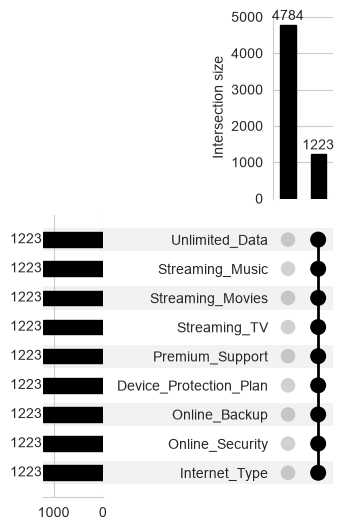

In [11]:
# Visualizacion de apariciones conjuntas de nulos en variables de internet
(
    df_model
    .missing
    .missing_upsetplot(
        variables=INTERNET_DEPENDENT_COLS,
        element_size=30,
        show_counts=True,
    )
)


### Conclusion

Tres evidencias independientes coinciden: el corte visual al ordenar por `Internet_Service`, la tabla de conteos (100% nulo sin internet, 0% con internet) y el UpSet plot (una sola combinacion dominante, sin combinaciones parciales). Los nulos de estas nueve columnas no son errores aleatorios de captura -- son estructurales, explicados por completo por `Internet_Service == "No"`.

Por eso se imputan como categoria explicita (`No Internet Service`) en `04_train_test_split.ipynb`, en vez de eliminar filas validas.

## Distribuciones numericas por churn

La comparacion usa `Monthly_Charge >= 0` para evitar que la anomalia detectada distorsione la lectura.

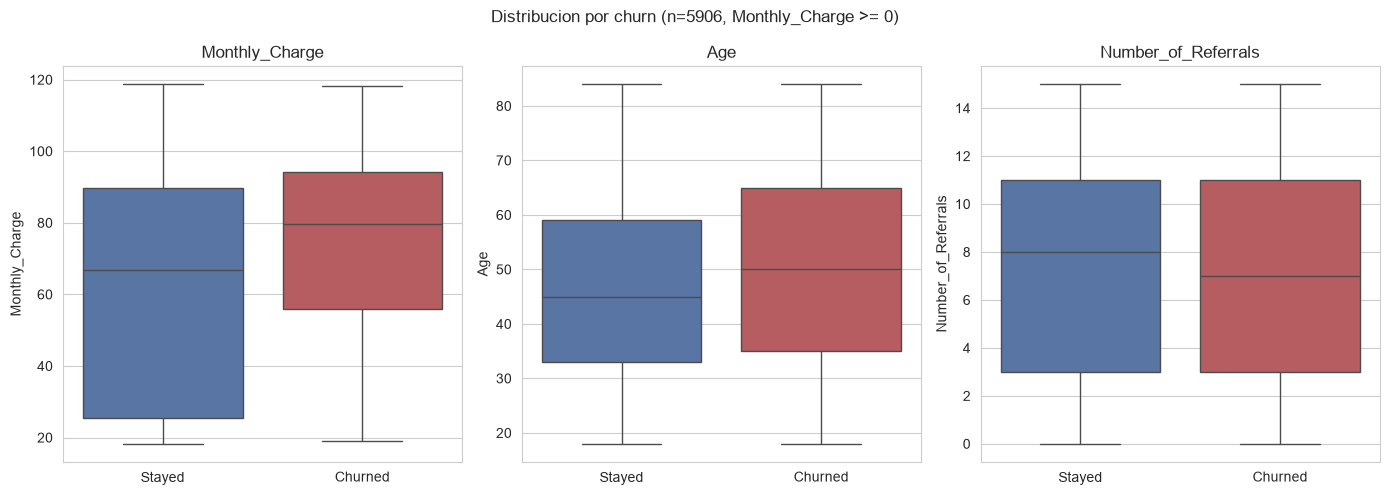

In [12]:
df_clean = df_model[df_model[MONTHLY_CHARGE_COL] >= 0].copy()
df_clean["churn_flag"] = (df_clean[TARGET_COL] == "Churned").astype(int)

box_cols = [MONTHLY_CHARGE_COL, "Age", "Number_of_Referrals"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, box_cols):
    sns.boxplot(data=df_clean, x=TARGET_COL, y=col, hue=TARGET_COL, palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle(f"Distribucion por churn (n={len(df_clean)}, Monthly_Charge >= 0)")
plt.tight_layout()
plt.show()

## Correlacion de variables numericas

La matriz mide correlacion Pearson contra variables numericas y `churn_flag` (`1 = Churned`). Sirve para priorizar relaciones, no para concluir causalidad.

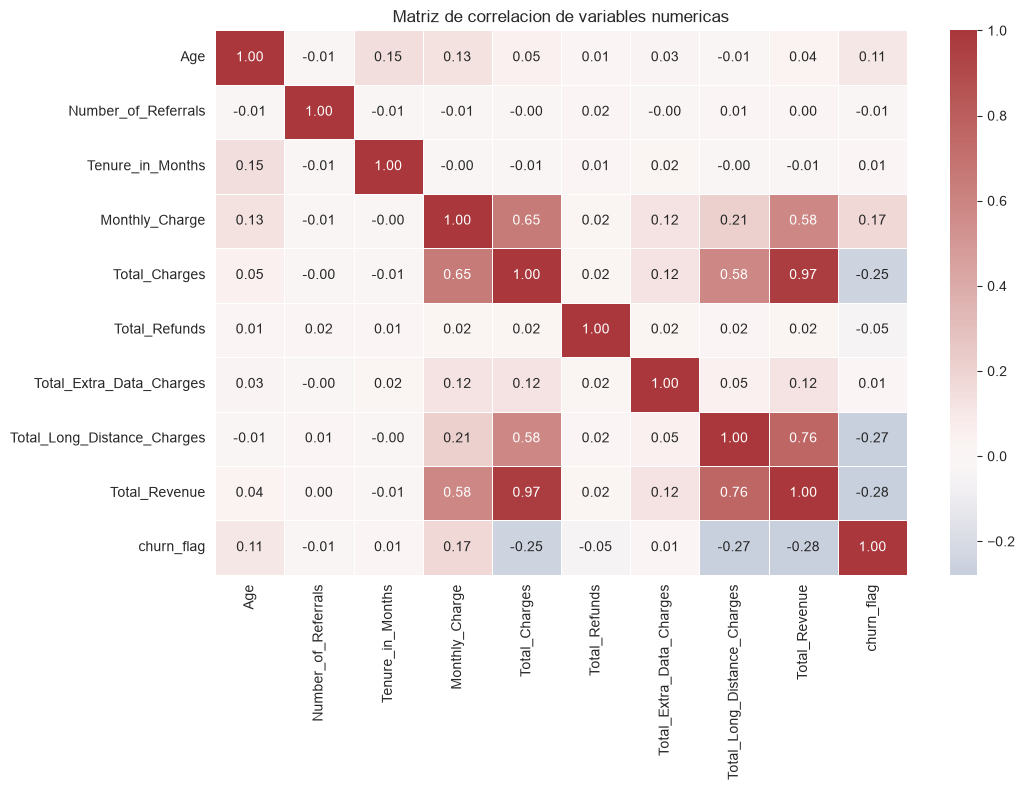

In [13]:
full_numeric_cols = [
    "Age", "Number_of_Referrals", "Tenure_in_Months", "Monthly_Charge",
    "Total_Charges", "Total_Refunds", "Total_Extra_Data_Charges",
    "Total_Long_Distance_Charges", "Total_Revenue", "churn_flag",
]
corr_matrix = df_clean[full_numeric_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=0.5)
plt.title("Matriz de correlacion de variables numericas")
plt.tight_layout()
plt.show()

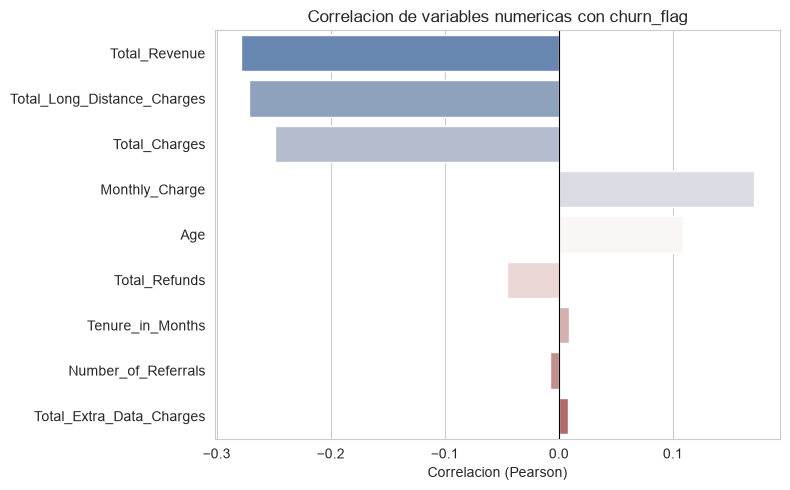

Total_Revenue                 -0.278804
Total_Long_Distance_Charges   -0.271306
Total_Charges                 -0.249086
Monthly_Charge                 0.171366
Age                            0.109168
Total_Refunds                 -0.045327
Tenure_in_Months               0.008592
Number_of_Referrals           -0.008000
Total_Extra_Data_Charges       0.007897
Name: churn_flag, dtype: float64

In [14]:
target_corr = corr_matrix["churn_flag"].drop("churn_flag").sort_values(key=lambda s: s.abs(), ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index, palette="vlag", legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlacion de variables numericas con churn_flag")
plt.xlabel("Correlacion (Pearson)")
plt.ylabel("")
plt.tight_layout()
plt.show()
target_corr

`Total_Revenue` (-0.28) y `Total_Charges` (-0.25) son, de hecho, la senal numerica mas fuerte con churn -- mas que `Monthly_Charge` (0.17). Tentador asumir que esto pasa porque capturan antiguedad del cliente, pero `Tenure_in_Months` correlaciona casi cero con ambas (-0.008 y -0.007) -- no es eso. La razon real por la que estas columnas se excluyen del modelo no es colinealidad con tenure, sino que su rango depende de cuanto tiempo lleva el cliente acumulando cargos desde el alta, lo que las deja fuera de rango para `Joined` (diagnosticado con datos en `03_statistical_analysis.ipynb`, aplicado en `04_train_test_split.ipynb`).

## Asociacion de variables categoricas con churn (Cramer's V)

Cramer's V permite comparar fuerza de asociacion entre variables categoricas y churn en una misma escala (0 a 1), a diferencia de un chi-cuadrado crudo que depende del tamano de muestra. Los nulos estructurales identificados arriba se convierten en categoria explicita antes del calculo -- de lo contrario, `pd.crosstab` los descartaria silenciosamente y el resultado quedaria sesgado hacia clientes con servicio de internet.

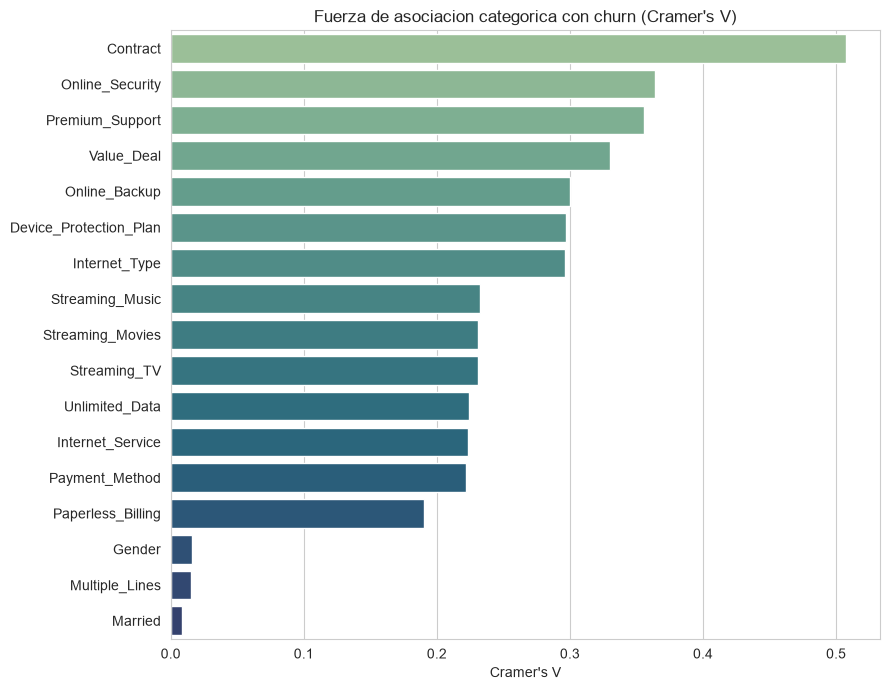

Contract                  0.507596
Online_Security           0.364002
Premium_Support           0.355460
Value_Deal                0.330278
Online_Backup             0.299758
Device_Protection_Plan    0.297311
Internet_Type             0.296477
Streaming_Music           0.232598
Streaming_Movies          0.230847
Streaming_TV              0.230656
Unlimited_Data            0.224165
Internet_Service          0.223465
Payment_Method            0.221944
Paperless_Billing         0.189989
Gender                    0.015871
Multiple_Lines            0.014880
Married                   0.008794
dtype: float64

In [15]:
import numpy as np


def cramers_v(x, y):
    table = pd.crosstab(x, y)
    observed = table.to_numpy(dtype=float)
    n = observed.sum()
    row_totals = observed.sum(axis=1, keepdims=True)
    col_totals = observed.sum(axis=0, keepdims=True)
    expected = row_totals @ col_totals / n
    chi2_stat = np.divide(
        (observed - expected) ** 2, expected,
        out=np.zeros_like(observed), where=expected > 0,
    ).sum()
    r, k = observed.shape
    return np.sqrt((chi2_stat / n) / max(1, min(k - 1, r - 1)))


categorical_cols = [
    "Contract", "Internet_Service", "Payment_Method", "Value_Deal",
    "Married", "Paperless_Billing", "Gender", "Multiple_Lines",
] + INTERNET_DEPENDENT_COLS

df_cat = df_clean.copy()
for col in INTERNET_DEPENDENT_COLS:
    df_cat[col] = df_cat[col].fillna("No Internet Service")
df_cat["Multiple_Lines"] = df_cat["Multiple_Lines"].fillna("No Phone Service")
df_cat["Value_Deal"] = df_cat["Value_Deal"].fillna("No Deal")

assoc = pd.Series(
    {col: cramers_v(df_cat[col], df_cat[TARGET_COL]) for col in categorical_cols}
).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(x=assoc.values, y=assoc.index, hue=assoc.index, palette="crest", legend=False)
plt.title("Fuerza de asociacion categorica con churn (Cramer's V)")
plt.xlabel("Cramer's V")
plt.ylabel("")
plt.tight_layout()
plt.show()
assoc

## Resumen

- `Contract` y `Value_Deal` son las variables categoricas con mayor asociacion con churn (Cramer's V); los servicios de internet aportan senal moderada.
- `Total_Revenue` y `Total_Charges` son la senal numerica mas fuerte con churn, pero no por antiguedad (correlacion con `Tenure_in_Months` es casi cero) -- se excluyen del modelo porque su rango depende de cuanto lleva el cliente acumulando cargos, lo que las deja fuera de rango para `Joined`.
- `Monthly_Charge` es una senal numerica util, pero requiere filtrar 107 filas negativas: son valores enteros de forma casi perfecta (100% vs. ~5.5% en el resto), evidencia de datos sinteticos, no de una regla de negocio real.
- Los nulos de las 9 columnas dependientes de internet son estructurales (`Internet_Service == "No"`), confirmados con tres evidencias independientes -- se imputan como categoria, no se eliminan filas.
- Las decisiones de limpieza y exclusion se aplican en `04_train_test_split.ipynb`; el diagnostico de `Total_Charges`/`Total_Revenue` fuera de rango para `Joined` se detalla en `03_statistical_analysis.ipynb`.